# Lab 2 - Time Domain Filtering
This lab is meant to give you an introduction to working with discrete time
signals and systems and implement some temporal filters in discrete time from
scratch using Python.

**Team Members**: Yunxiao Du, Yuwen Chen

In [6]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import pylab as pl
import time as t
import scipy

from IPython import display
from scipy.io import wavfile
from PIL import Image 
from scipy import signal
from scipy.signal import convolve2d

# Task 1: Application of Convolution

## 1.1 Polynomial Multiplication and Convolution
$$f(x) = 1 + 2x + 3x^2$$

$$g(x) = 4 + 5x + 6x^2$$

$$f(x) \cdot g(x) = (1 + 2x + 3x^2)(4 + 5x + 6x^2)$$

$$= 4 + 13x + 28x^2 + 27x^3 + 18x^4$$

The coefficients  are: [4, 13, 28, 27, 18]

In [7]:
f_coeffs = np.array([1, 2, 3])
g_coeffs = np.array([4, 5, 6])
result_coeffs = np.convolve(f_coeffs, g_coeffs)

print("Coefficients of f(x):", f_coeffs)
print("Coefficients of g(x):", g_coeffs)
print("Coefficients of f(x) * g(x):", result_coeffs)
print("Expected coefficients: [4, 13, 28, 27, 18]")
print(np.array_equal(result_coeffs, np.array([4, 13, 28, 27, 18])))

Coefficients of f(x): [1 2 3]
Coefficients of g(x): [4 5 6]
Coefficients of f(x) * g(x): [ 4 13 28 27 18]
Expected coefficients: [4, 13, 28, 27, 18]
True


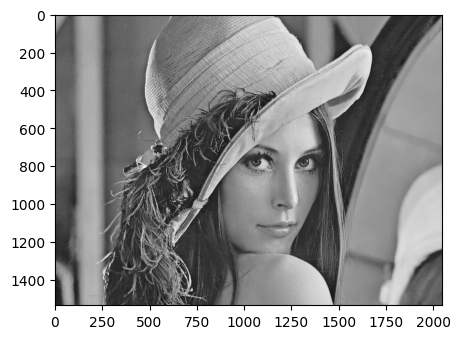

In [8]:
img_gray = Image.open('lenna.jpeg').convert('L')    # Uses standard 8-bit color code (integer)
img_gray = np.array(img_gray)                    # Convert to numpy array

fig = plt.figure(figsize=(5, 5))
_ = plt.imshow(img_gray, cmap ='gray', vmin=0, vmax=255)

In [9]:
kernel_size = 20
smooth_kernel = np.ones((kernel_size, kernel_size)) / kernel_size**2

horiz_edge_kernel = np.array([[-1, -2, -1],
                              [ 0,  0,  0],
                              [ 1,  2,  1]])

vert_edge_kernel = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])

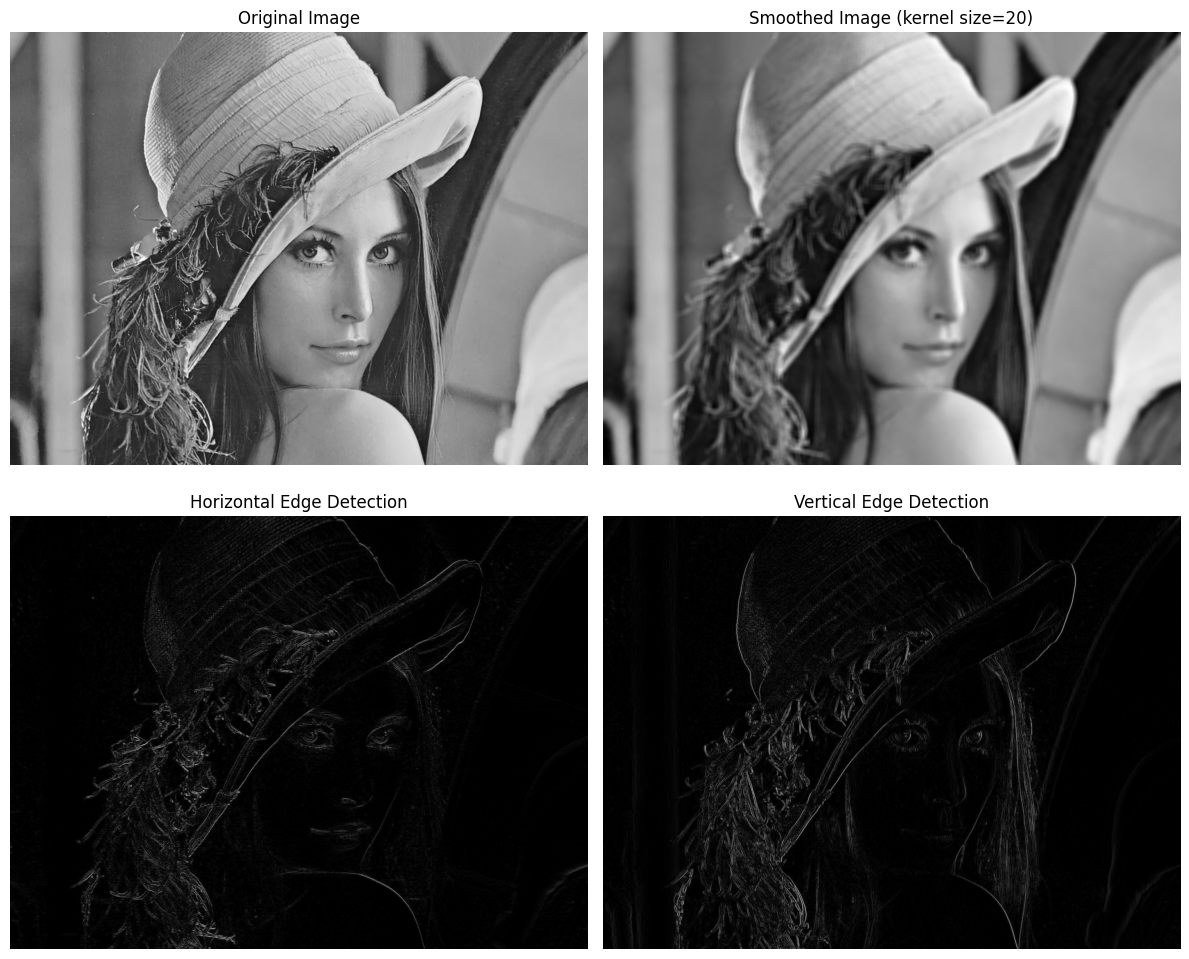

In [10]:
img_smooth = signal.convolve2d(img_gray, smooth_kernel, mode='same', boundary='symm')

img_horiz_edge = signal.convolve2d(img_gray, horiz_edge_kernel, mode='same', boundary='symm')

img_vert_edge = signal.convolve2d(img_gray, vert_edge_kernel, mode='same', boundary='symm')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original image
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Smoothed image
axes[0, 1].imshow(img_smooth, cmap='gray')
axes[0, 1].set_title(f'Smoothed Image (kernel size={kernel_size})')
axes[0, 1].axis('off')

# Horizontal edge detection
axes[1, 0].imshow(np.abs(img_horiz_edge), cmap='gray')
axes[1, 0].set_title('Horizontal Edge Detection')
axes[1, 0].axis('off')

# Vertical edge detection
axes[1, 1].imshow(np.abs(img_vert_edge), cmap='gray')
axes[1, 1].set_title('Vertical Edge Detection')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Explaination

Smooth Kernel:
The smooth kernel is a uniform averaging filter. Each pixel is replaced by the average of its neighboring pixels. This acts as a Low-Pass filter, removing high-frequency details and creating a blurred effect.

Horizontal Edge Kernel:
The horizontal edge kernel detects horizontal edges by computing the gradient in the vertical direction. It acts as a High-Pass filter that highlights regions where pixel intensity changes rapidly in the vertical direction.


# Task 2: Implementing Discrete Time Filters to Filter Time-Series Data

In this part, we will look at various discrete time filters and how they are used to make more sense of time-series data. These are very common, basic and helpful operations that one encounters in anything related to signal processing.

## 2.1 Implementing a Mean Filter

### n is an array containing integers from -5 to 6 (exclusive) with a step size of 1. 

In [11]:
n = np.arange(-5, 6, 1)
print(n)

[-5 -4 -3 -2 -1  0  1  2  3  4  5]


In [12]:
# choose relevant parameters
srate = 1000 # sampling rate in Hz
time = np.arange(0, 3, 1/srate) # associated time vector that corresponds to 3 seconds
n = len(time) # length of the time vector
p = 15 # poles for random interpolation
pi = np.pi # value of pi
sigamp1 = 30 # amplitude of base signal 1
sigamp2 = 5 # amplitude of base 
2

# here are some base signals to work with
base1 = np.interp(np.linspace(0,p,n),np.arange(0,p),np.random.rand(p)*sigamp1)
# np.interp(x, xp, fp)
# Returns the one-dimensional piecewise linear interpolant to a function with given discrete data points (xp, fp), evaluated at x.

base2 = 5*np.sin(2*pi*sigamp2*time)

In [ ]:
# Plot base signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(time, base1)
axes[0].set_title('Base Signal 1 (Random Interpolation)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(time, base2)
axes[1].set_title('Base Signal 2 (Sinusoidal)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
# create some random noise to be added to the above base signals
noiseamp = 1  # noise amplitude (can be adjusted to see effect)
noise = noiseamp * np.random.randn(n)

# add noise to the base signals to create new noisy signals
signal1 = base1 + noise
signal2 = base2 + noise

In [ ]:
# implement the running mean filter
k = 20  # number of points on each side of the current point

filtsig1 = np.zeros(n)  # initialize filtered signal vector for signal 1
filtsig2 = np.zeros(n)  # initialize filtered signal vector for signal 2

# Apply running mean filter
# Loop through signal points starting from k to n-k
for i in range(k, n-k):
    # Replace each point by the average of k points before, k points after, and the point itself
    filtsig1[i] = np.mean(signal1[i-k:i+k+1])
    filtsig2[i] = np.mean(signal2[i-k:i+k+1])

# Handle edge cases (first k and last k points) - copy original values
filtsig1[:k] = signal1[:k]
filtsig1[n-k:] = signal1[n-k:]
filtsig2[:k] = signal2[:k]
filtsig2[n-k:] = signal2[n-k:]

# compute the time window size in ms and print it
# Window size = 2*k + 1 points, each point is 1/srate seconds apart
windowsize = (2*k + 1) * (1/srate) * 1000  # convert to ms

print("The time window size used was ", windowsize, "ms")

In [ ]:
# Plot results for base signal 1
fig1, axes1 = plt.subplots(3, 1, figsize=(12, 8))

# Original signal
axes1[0].plot(time, base1)
axes1[0].set_title('Original Signal')
axes1[0].set_xlabel('Time (s)')
axes1[0].set_ylabel('Amplitude')

# Noisy signal
axes1[1].plot(time, signal1)
axes1[1].set_title('Noisy Signal')
axes1[1].set_xlabel('Time (s)')
axes1[1].set_ylabel('Amplitude')

# Filtered signal overlaid on noisy signal
axes1[2].plot(time, signal1, label='noisy', alpha=0.7)
axes1[2].plot(time, filtsig1, label='filtered', linewidth=2)
axes1[2].set_title(f'Noisy and Filtered Signal with noiseamp={noiseamp}')
axes1[2].set_xlabel('Time (s)')
axes1[2].set_ylabel('Amplitude')
axes1[2].legend()

plt.tight_layout()
plt.show()

# Plot results for base signal 2
fig2, axes2 = plt.subplots(3, 1, figsize=(12, 8))

# Original signal
axes2[0].plot(time, base2)
axes2[0].set_title('Original Signal')
axes2[0].set_xlabel('Time (s)')
axes2[0].set_ylabel('Amplitude')

# Noisy signal
axes2[1].plot(time, signal2)
axes2[1].set_title('Noisy Signal')
axes2[1].set_xlabel('Time (s)')
axes2[1].set_ylabel('Amplitude')

# Filtered signal overlaid on noisy signal
axes2[2].plot(time, signal2, label='noisy', alpha=0.7)
axes2[2].plot(time, filtsig2, label='filtered', linewidth=2)
axes2[2].set_title(f'Noisy and Filtered Signal with noiseamp={noiseamp}')
axes2[2].set_xlabel('Time (s)')
axes2[2].set_ylabel('Amplitude')
axes2[2].legend()

plt.tight_layout()
plt.show()

## Discussion

**Comment on how the results and plots change when you amplify the noise more and also change the value of k.**




**Mention and explain any ONE of many possible drawbacks of the mean filter in analysing noisy time-series?**



## 2.2 Implementing a Median Filter to Remove Spikes

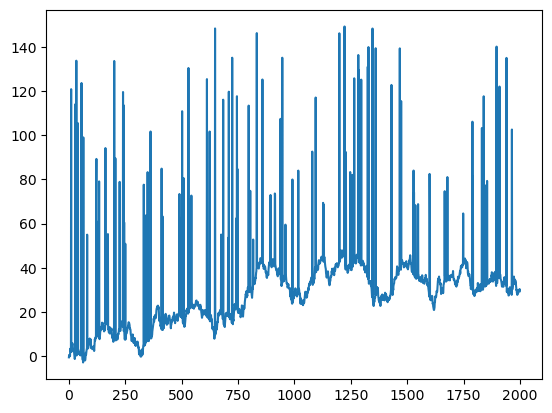

In [12]:
# create signal
n = 2000
# np.cumsum calculates the cumulative sum of elements along a given axis. 
# signal array represents the cumulative sum of the random values
signal = np.cumsum(np.random.randn(n))

# proportion of time points to replace with noise
propnoise = .05

# find noise points
noisepnts = np.random.permutation(n)
noisepnts = noisepnts[0:int(n*propnoise)]

# generate signal and replace points with noise
signal[noisepnts] = 50+np.random.rand(len(noisepnts))*100

fig3=plt.figure(3)
plt.plot(range(0,n),signal)

In [ ]:
# Plot histogram to pick threshold
fig, ax = plt.subplots(figsize=(10, 4))
plt.hist(signal, bins=50)
plt.title('Histogram of Noisy Signal')
plt.xlabel('Signal')
plt.ylabel('Count')
plt.show()

# visual-picked threshold (spikes are above ~50 based on how signal was created)
threshold = 40

# find data values above the threshold
suprathresh = np.where(signal > threshold)[0]

# initialize filtered signal
filtsig = copy.deepcopy(signal)

# loop through suprathreshold points and set to median of k
k = 20  # actual window is k*2+1
for ti in range(len(suprathresh)):
    # Get the index of the current suprathreshold point
    idx = suprathresh[ti]
    
    # lower and upper bounds (handle edge cases)
    lower = max(0, idx - k)
    upper = min(n, idx + k + 1)
    
    # compute median of surrounding points
    filtsig[idx] = np.median(signal[lower:upper])

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Noisy signal
axes[0].plot(range(n), signal)
axes[0].set_title('Noisy Signal')
axes[0].set_xlabel('time')
axes[0].set_ylabel('Signal')

# Histogram
axes[1].hist(signal, bins=50)
axes[1].set_title('Histogram of Noisy Signal')
axes[1].set_xlabel('Signal')
axes[1].set_ylabel('Count')

# Noisy and filtered signal overlaid
axes[2].plot(range(n), signal, label='noisy')
axes[2].plot(range(n), filtsig, label='filtered')
axes[2].set_title('Noisy Signal and Filtered Signal')
axes[2].set_xlabel('time')
axes[2].set_ylabel('Signal')
axes[2].legend()

plt.tight_layout()
plt.show()

## Discussion

**Compare the mean and median filters in terms of their uses and one advantage and disadvantage one has over the other.**

## Task 3: Denoising an EMG signal

In [ ]:
# import data
emgdata = scipy.io.loadmat('EMG.mat')

# extract needed variables
emgtime = emgdata['emgtime'][0]
emg = emgdata['emg'][0]

# initialize filtered signal
emgf = copy.deepcopy(emg)  # this is where the result of the TKEO algorithm should be stored

# apply the TKEO algorithm: y_t = x_t^2 - x_{t+1} * x_{t-1}
# Using vectorized approach for efficiency
# For indices 1 to n-2 (avoiding boundary issues)
emgf[1:-1] = emg[1:-1]**2 - emg[2:] * emg[:-2]

# Handle boundary points (first and last points can't use the formula)
emgf[0] = emgf[1]
emgf[-1] = emgf[-2]

## convert both signals to zscore

# find timepoint zero (index where time is closest to 0)
time0 = np.argmin(np.abs(emgtime))
print(f"Time zero index: {time0}")

# convert original EMG to z-score from time-zero
# Use baseline (before time 0) to calculate mean and std
baseline_emg = emg[:time0]
emgZ = (emg - np.mean(baseline_emg)) / np.std(baseline_emg)

# same for filtered EMG energy
baseline_emgf = emgf[:time0]
emgZf = (emgf - np.mean(baseline_emgf)) / np.std(baseline_emgf)

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Un-scaled TKEO method (normalized by max value)
emg_norm = emg / np.max(np.abs(emg))
emgf_norm = emgf / np.max(np.abs(emgf))

axes[0].plot(emgtime, emg_norm, label='EMG')
axes[0].plot(emgtime, emgf_norm, label='TKEO energy')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude or energy')
axes[0].set_title('EMG Signal and TKEO Energy (Normalized)')
axes[0].legend()
axes[0].set_xlim([emgtime[0], emgtime[-1]])

# Plot 2: Z-score scaled results
axes[1].plot(emgtime, emgZ, label='EMG')
axes[1].plot(emgtime, emgZf, label='TKEO energy')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Z-score relative to pre-stimulus')
axes[1].set_title('EMG Signal and TKEO Energy (Z-score Scaled)')
axes[1].legend()
axes[1].set_xlim([emgtime[0], emgtime[-1]])

plt.tight_layout()
plt.show()

## Discussion

**How would the other two filters implemented, i.e, the running mean and median filters fare against the TKEO method in analysing the EMG signal in this fashion?**



**If you had to use a running mean filter or a median filter to analyse the EMG signal to detect muscle activity, which one would you prefer and why?**

